In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dataset.csv")
df.head()

,text,clean_text,style,tone
0,Do not ever attempt to bypass the established ...,do not ever attempt to bypass the established ...,business,aggressive
1,We will not tolerate this kind of insubordinat...,we will not tolerate this kind of insubordinat...,formal,aggressive
2,If these heavily revised regional sales quotas...,if these heavily revise regional sale quota be...,business,aggressive
3,"The sudden, highly alarming drop in local ecol...","the sudden , highly alarming drop in local eco...",academic,urgent
4,Message Passing Interface was utilized to mana...,message passing interface be utilize to manage...,academic,neutral


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        500 non-null    str  
 1   clean_text  500 non-null    str  
 2   style       500 non-null    str  
 3   tone        500 non-null    str  
dtypes: str(4)
memory usage: 15.8 KB


In [4]:
df.isnull().sum()

text          0
clean_text    0
style         0
tone          0
dtype: int64

style
business    100
formal      100
academic    100
informal    100
literary    100
Name: count, dtype: int64


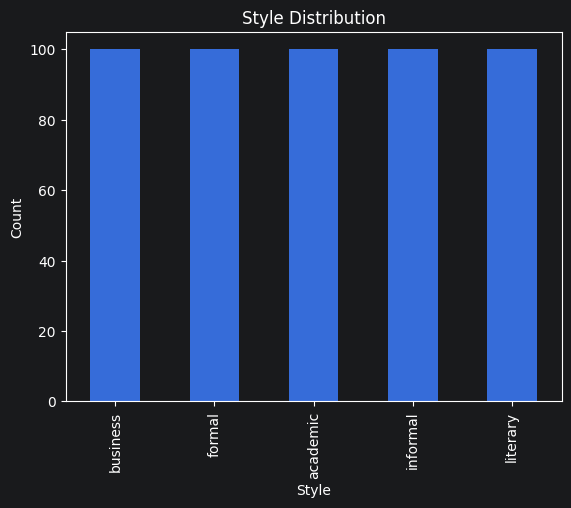

In [5]:
style_counts = df["style"].value_counts()

print(style_counts)

style_counts.plot(kind="bar")

plt.title("Style Distribution")
plt.xlabel("Style")
plt.ylabel("Count")

plt.show()

tone
aggressive    100
urgent        100
neutral       100
friendly      100
sarcastic     100
Name: count, dtype: int64


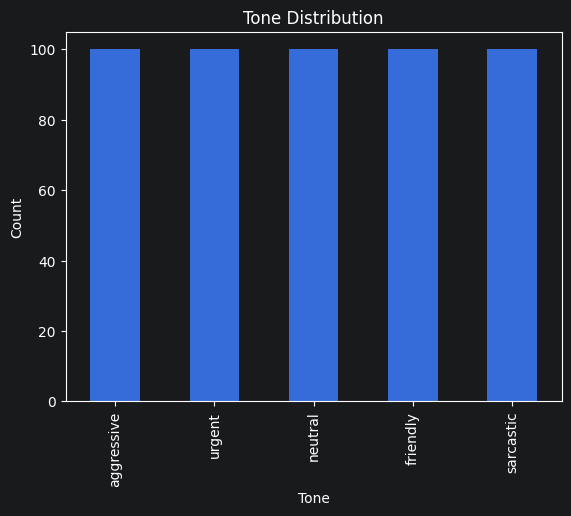

In [6]:
tone_counts = df["tone"].value_counts()

print(tone_counts)

tone_counts.plot(kind="bar")

plt.title("Tone Distribution")
plt.xlabel("Tone")
plt.ylabel("Count")

plt.show()

tone      aggressive  friendly  neutral  sarcastic  urgent
style                                                     
academic          20        20       20         20      20
business          20        20       20         20      20
formal            20        20       20         20      20
informal          20        20       20         20      20
literary          20        20       20         20      20


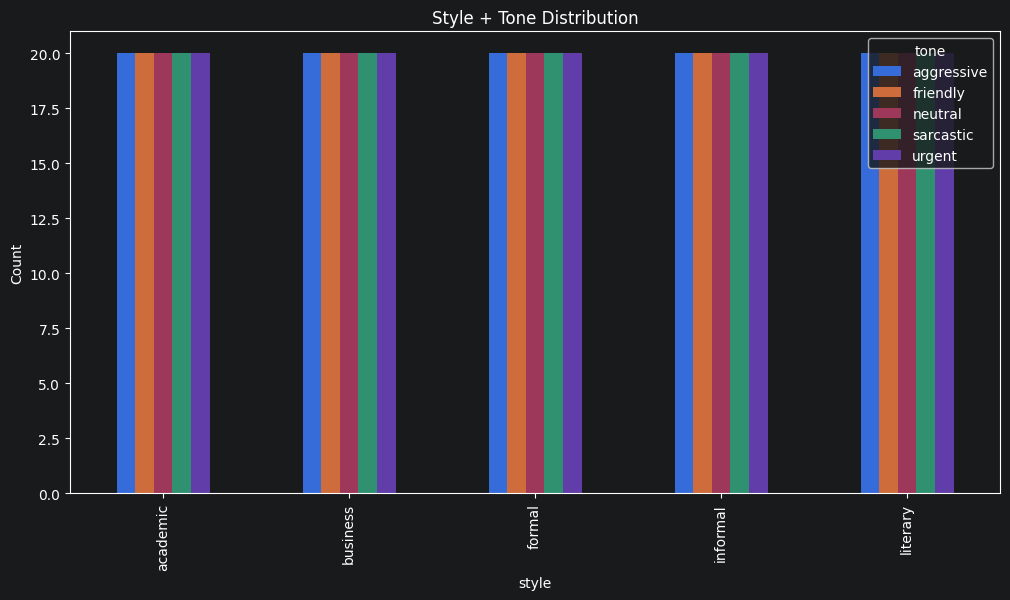

In [7]:
combo_counts = (
    df.groupby(["style", "tone"])
      .size()
      .unstack(fill_value=0)
)

print(combo_counts)

combo_counts.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Style + Tone Distribution")
plt.ylabel("Count")

plt.show()

In [8]:
df["clean_text"] = df["text"].astype(str)
df["text_length"] = df["clean_text"].apply(len)

df["text_length"].describe()

count     500.000000
mean      201.734000
std       147.353403
min         9.000000
25%        93.000000
50%       204.500000
75%       279.500000
max      1194.000000
Name: text_length, dtype: float64

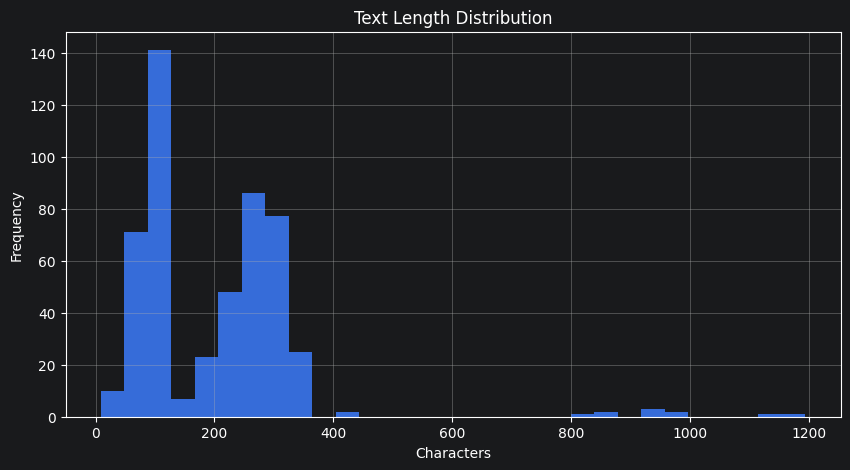

In [9]:
df["text_length"].hist(
    bins=30,
    figsize=(10, 5)
)

plt.title("Text Length Distribution")

plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

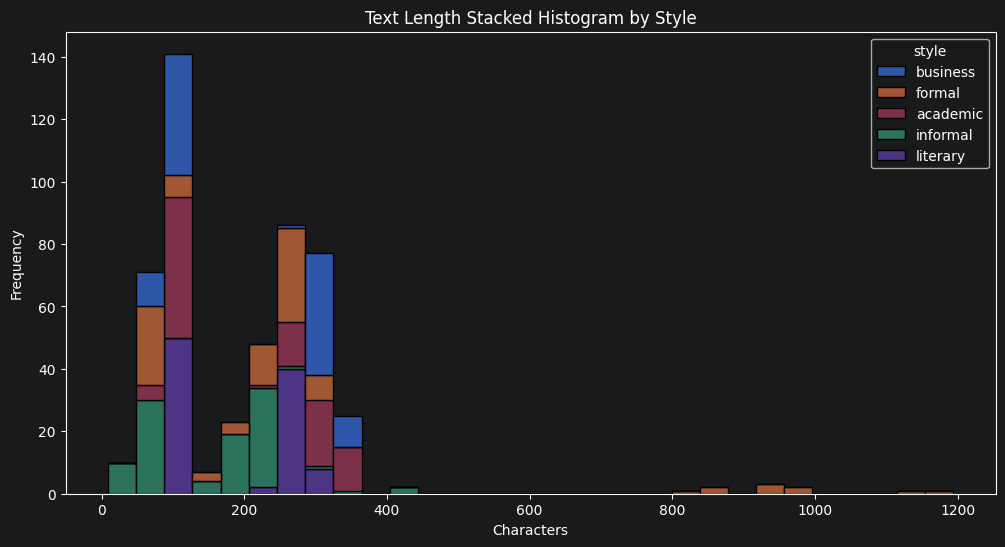

In [15]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x="text_length",
    hue="style",
    multiple="stack",
    bins=30
)
plt.title("Text Length Stacked Histogram by Style")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

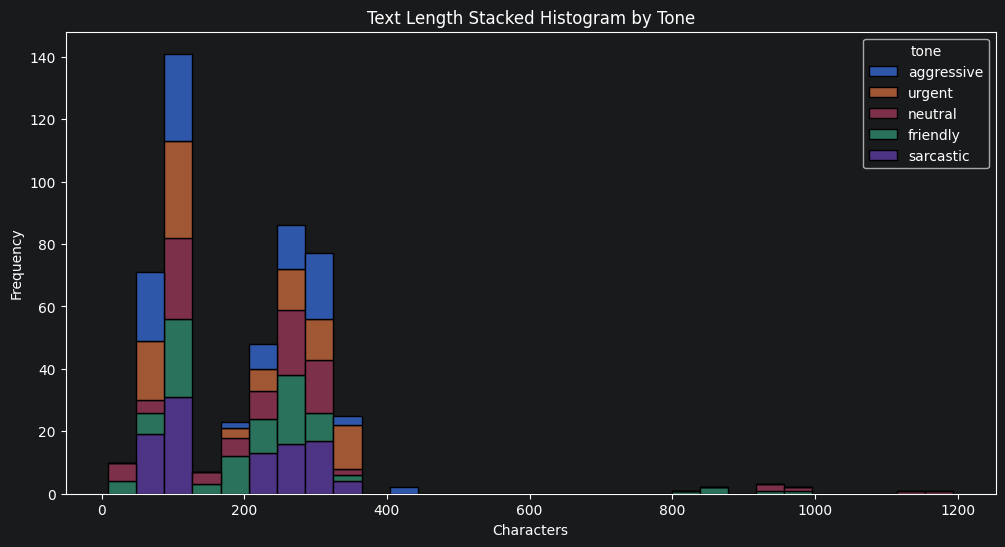

In [16]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x="text_length",
    hue="tone",
    multiple="stack",
    bins=30
)
plt.title("Text Length Stacked Histogram by Tone")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()